In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os
pd.set_option('display.max_columns', 60)
os.makedirs("../results", exist_ok=True)
os.makedirs("../results/figures", exist_ok=True)

In [2]:
# ---- Load all artifacts ----
master = pd.read_csv("../data/master_clean.csv")

esm_data = np.load("../data/features_esm2.npz", allow_pickle=True)
esm_X_all = esm_data['X']
esm_accs = list(esm_data['accs'])
esm_idx = {acc: i for i, acc in enumerate(esm_accs)}

bp = pd.read_csv("../data/features_GO_BP_slim.csv", index_col=0)
mf = pd.read_csv("../data/features_GO_MF_slim.csv", index_col=0)
cc = pd.read_csv("../data/features_GO_CC_slim.csv", index_col=0)

print(f"ESM-2: {esm_X_all.shape}")
print(f"BP slim: {bp.shape}, MF slim: {mf.shape}, CC slim: {cc.shape}")

# Restrict to proteins with ESM-2 embedding AND valid cluster
keep = master['acc'].isin(esm_accs) & master['cluster'].notna()
master = master[keep].reset_index(drop=True)
y = master['d2o'].values.astype(int)
groups = master['cluster'].astype(int).values
print(f"\nFinal modelling set: {len(master)} proteins, "
      f"{y.sum()} positives, {len(np.unique(groups))} clusters")

# ---- The factorial-condition feature builder ----
# Bit-encoded condition_id: bit 0 = BP, bit 1 = MF, bit 2 = CC. Condition 1 = sequence only.
CONDITIONS = {
    1: {'label': 'Seq only',          'bp': False, 'mf': False, 'cc': False},
    2: {'label': 'Seq + BP',          'bp': True,  'mf': False, 'cc': False},
    3: {'label': 'Seq + MF',          'bp': False, 'mf': True,  'cc': False},
    4: {'label': 'Seq + CC',          'bp': False, 'mf': False, 'cc': True },
    5: {'label': 'Seq + BP + MF',     'bp': True,  'mf': True,  'cc': False},
    6: {'label': 'Seq + BP + CC',     'bp': True,  'mf': False, 'cc': True },
    7: {'label': 'Seq + MF + CC',     'bp': False, 'mf': True,  'cc': True },
    8: {'label': 'Seq + BP + MF + CC','bp': True,  'mf': True,  'cc': True },
}

def make_X(condition_id):
    cfg = CONDITIONS[condition_id]
    X_seq = np.stack([esm_X_all[esm_idx[a]] for a in master['acc']])
    parts = [X_seq]
    for slim_mat, present in [(bp, cfg['bp']), (mf, cfg['mf']), (cc, cfg['cc'])]:
        if present:
            parts.append(slim_mat.reindex(master['acc']).fillna(0).values)
    return np.hstack(parts).astype(np.float32)

# Sanity-check dimensions
for cid in range(1, 9):
    X = make_X(cid)
    print(f"Condition {cid} ({CONDITIONS[cid]['label']}): X.shape = {X.shape}")

ESM-2: (1279, 1280)
BP slim: (866, 64), MF slim: (1014, 36), CC slim: (1120, 25)

Final modelling set: 1279 proteins, 188 positives, 1168 clusters
Condition 1 (Seq only): X.shape = (1279, 1280)
Condition 2 (Seq + BP): X.shape = (1279, 1344)
Condition 3 (Seq + MF): X.shape = (1279, 1316)
Condition 4 (Seq + CC): X.shape = (1279, 1305)
Condition 5 (Seq + BP + MF): X.shape = (1279, 1380)
Condition 6 (Seq + BP + CC): X.shape = (1279, 1369)
Condition 7 (Seq + MF + CC): X.shape = (1279, 1341)
Condition 8 (Seq + BP + MF + CC): X.shape = (1279, 1405)


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (average_precision_score, f1_score,
                             balanced_accuracy_score, roc_auc_score,
                             matthews_corrcoef)

# Predefine CV splits ONCE so all conditions are paired by fold
cv = GroupKFold(n_splits=5)
splits = list(cv.split(np.zeros(len(master)), y, groups))
for fold, (tr, te) in enumerate(splits):
    assert len(set(groups[tr]) & set(groups[te])) == 0
    print(f"Fold {fold}: train {len(tr)} ({y[tr].sum()} pos, "
          f"{len(set(groups[tr]))} clusters) → "
          f"test {len(te)} ({y[te].sum()} pos, {len(set(groups[te]))} clusters)")

# Threshold note: use the prevalence (~0.147) instead of 0.5 to dodge the
# all-negative artifact we hit in W5. Optimal threshold per fold is also
# fine, but a fixed prevalence-based threshold is cleaner for comparability.
THRESHOLD = float(y.mean())
print(f"\nUsing classification threshold = {THRESHOLD:.3f} (prevalence)")

Fold 0: train 1023 (154 pos, 935 clusters) → test 256 (34 pos, 233 clusters)
Fold 1: train 1023 (146 pos, 934 clusters) → test 256 (42 pos, 234 clusters)
Fold 2: train 1023 (154 pos, 934 clusters) → test 256 (34 pos, 234 clusters)
Fold 3: train 1023 (152 pos, 934 clusters) → test 256 (36 pos, 234 clusters)
Fold 4: train 1024 (146 pos, 935 clusters) → test 255 (42 pos, 233 clusters)

Using classification threshold = 0.147 (prevalence)


In [4]:
results_rf = []
for cid in range(1, 9):
    cfg = CONDITIONS[cid]
    X = make_X(cid)
    print(f"\n=== Condition {cid}: {cfg['label']} (X shape {X.shape}) ===")
    for fold, (tr, te) in enumerate(splits):
        clf = RandomForestClassifier(
            n_estimators=500, class_weight='balanced',
            min_samples_leaf=3, n_jobs=-1, random_state=42)
        clf.fit(X[tr], y[tr])
        proba = clf.predict_proba(X[te])[:, 1]
        pred = (proba >= THRESHOLD).astype(int)
        results_rf.append({
            'condition': cid,
            'label': cfg['label'],
            'fold': fold,
            'n_test': len(te),
            'n_pos_test': int(y[te].sum()),
            'auprc':    average_precision_score(y[te], proba),
            'auroc':    roc_auc_score(y[te], proba),
            'macro_f1': f1_score(y[te], pred, average='macro'),
            'bal_acc':  balanced_accuracy_score(y[te], pred),
            'mcc':      matthews_corrcoef(y[te], pred),
        })
        r = results_rf[-1]
        print(f"  Fold {fold}: AUPRC={r['auprc']:.3f}, AUROC={r['auroc']:.3f}, "
              f"F1={r['macro_f1']:.3f}, MCC={r['mcc']:.3f}")

results_rf = pd.DataFrame(results_rf)
results_rf.to_csv("../results/factorial_rf_per_fold.csv", index=False)
print("\nDone. Saved per-fold scores.")


=== Condition 1: Seq only (X shape (1279, 1280)) ===
  Fold 0: AUPRC=0.163, AUROC=0.556, F1=0.323, MCC=0.063
  Fold 1: AUPRC=0.192, AUROC=0.530, F1=0.440, MCC=0.046
  Fold 2: AUPRC=0.152, AUROC=0.503, F1=0.340, MCC=0.009
  Fold 3: AUPRC=0.190, AUROC=0.581, F1=0.347, MCC=0.107
  Fold 4: AUPRC=0.299, AUROC=0.725, F1=0.461, MCC=0.233

=== Condition 2: Seq + BP (X shape (1279, 1344)) ===
  Fold 0: AUPRC=0.159, AUROC=0.543, F1=0.329, MCC=0.050
  Fold 1: AUPRC=0.197, AUROC=0.545, F1=0.399, MCC=-0.002
  Fold 2: AUPRC=0.145, AUROC=0.510, F1=0.353, MCC=0.056
  Fold 3: AUPRC=0.191, AUROC=0.577, F1=0.360, MCC=0.156
  Fold 4: AUPRC=0.253, AUROC=0.673, F1=0.433, MCC=0.163

=== Condition 3: Seq + MF (X shape (1279, 1316)) ===
  Fold 0: AUPRC=0.176, AUROC=0.562, F1=0.332, MCC=0.053
  Fold 1: AUPRC=0.195, AUROC=0.539, F1=0.437, MCC=0.054
  Fold 2: AUPRC=0.153, AUROC=0.535, F1=0.340, MCC=0.043
  Fold 3: AUPRC=0.196, AUROC=0.592, F1=0.352, MCC=0.130
  Fold 4: AUPRC=0.278, AUROC=0.705, F1=0.438, MCC=0.2

                              auprc         auroc        macro_f1        bal_acc           mcc       
                               mean    std   mean    std     mean    std    mean    std   mean    std
condition label                                                                                      
1         Seq only            0.199  0.058  0.579  0.087    0.382  0.063   0.559  0.055  0.092  0.087
2         Seq + BP            0.189  0.042  0.570  0.063    0.375  0.041   0.554  0.045  0.085  0.072
3         Seq + MF            0.200  0.047  0.587  0.070    0.380  0.053   0.563  0.045  0.098  0.072
4         Seq + CC            0.194  0.057  0.577  0.078    0.383  0.055   0.568  0.044  0.107  0.072
5         Seq + BP + MF       0.203  0.053  0.580  0.069    0.372  0.056   0.546  0.062  0.074  0.099
6         Seq + BP + CC       0.205  0.049  0.584  0.076    0.382  0.063   0.562  0.061  0.097  0.096
7         Seq + MF + CC       0.193  0.056  0.581  0.078    0.376  0.054   0.551  

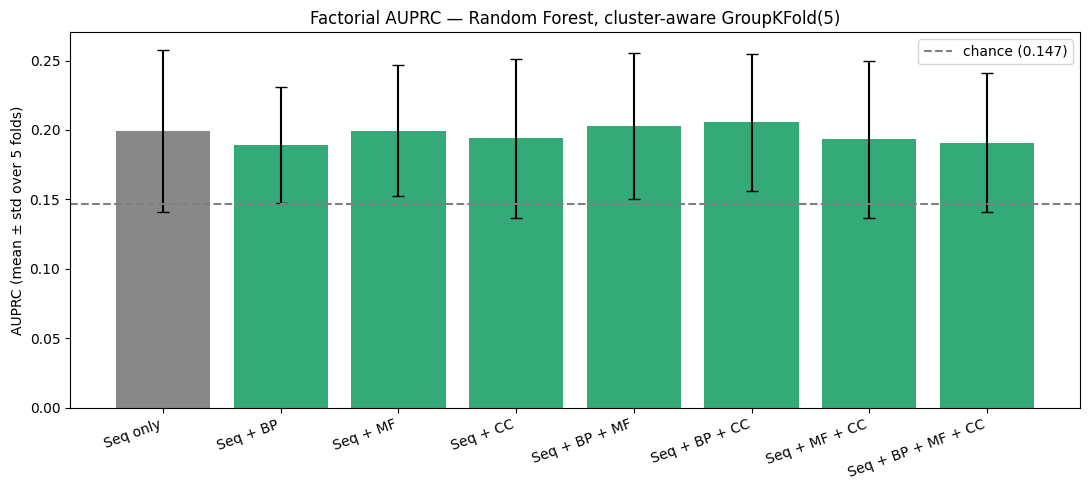

In [5]:
agg = (results_rf.groupby(['condition','label'])
                 [['auprc','auroc','macro_f1','bal_acc','mcc']]
                 .agg(['mean','std'])
                 .round(3))
print(agg.to_string())

# Quick-look bar chart
fig, ax = plt.subplots(figsize=(11, 5))
means = results_rf.groupby('condition')['auprc'].mean()
stds  = results_rf.groupby('condition')['auprc'].std()
labels = [CONDITIONS[c]['label'] for c in means.index]
ax.bar(range(1, 9), means.values, yerr=stds.values, capsize=4,
       color=['#888'] + ['#3a7']*7)
ax.set_xticks(range(1, 9)); ax.set_xticklabels(labels, rotation=20, ha='right')
ax.axhline(y[0:].mean(), ls='--', color='gray',
           label=f"chance ({y.mean():.3f})")
ax.set_ylabel("AUPRC (mean ± std over 5 folds)")
ax.set_title("Factorial AUPRC — Random Forest, cluster-aware GroupKFold(5)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/factorial_rf_auprc.png", dpi=150)
plt.show()

In [6]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# Wide view: rows = folds, columns = conditions
wide = results_rf.pivot(index='fold', columns='condition', values='auprc')

# ---- Pairwise: condition c vs condition 1 (baseline) ----
control = wide[1].values
rows = []
for cid in range(2, 9):
    other = wide[cid].values
    diff = other - control
    w, p = wilcoxon(other, control, alternative='greater', zero_method='wilcox')
    # Bootstrap CI of mean paired difference
    rng = np.random.default_rng(42)
    boots = [diff[rng.integers(0, len(diff), len(diff))].mean()
             for _ in range(2000)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    rows.append({
        'condition': cid,
        'label': CONDITIONS[cid]['label'],
        'mean_diff_vs_seq': diff.mean(),
        'ci95_lo': lo, 'ci95_hi': hi,
        'wilcoxon_W': w, 'p_raw': p,
    })
pair = pd.DataFrame(rows)
pair['p_BH'] = multipletests(pair['p_raw'], method='fdr_bh')[1]
pair = pair.round({'mean_diff_vs_seq': 3, 'ci95_lo': 3, 'ci95_hi': 3,
                   'p_raw': 4, 'p_BH': 4})
print("=== Pairwise vs condition 1 (Seq only), BH-corrected ===")
print(pair.to_string(index=False))

# ---- Factorial main and interaction effects (on AUPRC) ----
# Each condition is identified by a (BP, MF, CC) triple of 0/1.
flags = pd.DataFrame([
    {'condition': c, 'BP': int(CONDITIONS[c]['bp']),
                     'MF': int(CONDITIONS[c]['mf']),
                     'CC': int(CONDITIONS[c]['cc'])}
    for c in range(1, 9)])
wlong = wide.stack().rename('auprc').reset_index()
wlong = wlong.merge(flags, on='condition')

def main_effect(col):
    on  = wlong[wlong[col] == 1]['auprc'].mean()
    off = wlong[wlong[col] == 0]['auprc'].mean()
    return on - off

def interaction(col_a, col_b):
    # Difference of differences
    g11 = wlong[(wlong[col_a]==1) & (wlong[col_b]==1)]['auprc'].mean()
    g10 = wlong[(wlong[col_a]==1) & (wlong[col_b]==0)]['auprc'].mean()
    g01 = wlong[(wlong[col_a]==0) & (wlong[col_b]==1)]['auprc'].mean()
    g00 = wlong[(wlong[col_a]==0) & (wlong[col_b]==0)]['auprc'].mean()
    return (g11 - g10) - (g01 - g00)

print("\n=== Factorial effects on AUPRC ===")
print(f"  Main effect BP : {main_effect('BP'):+.4f}")
print(f"  Main effect MF : {main_effect('MF'):+.4f}")
print(f"  Main effect CC : {main_effect('CC'):+.4f}")
print(f"  Interaction BP×MF : {interaction('BP','MF'):+.4f}")
print(f"  Interaction BP×CC : {interaction('BP','CC'):+.4f}")
print(f"  Interaction MF×CC : {interaction('MF','CC'):+.4f}")

pair.to_csv("../results/factorial_rf_stats.csv", index=False)

=== Pairwise vs condition 1 (Seq only), BH-corrected ===
 condition              label  mean_diff_vs_seq  ci95_lo  ci95_hi  wilcoxon_W  p_raw   p_BH
         2           Seq + BP            -0.010   -0.028    0.002         4.0 0.8438 0.9375
         3           Seq + MF             0.000   -0.011    0.009        10.0 0.3125 0.7292
         4           Seq + CC            -0.005   -0.012    0.003         3.0 0.9062 0.9375
         5      Seq + BP + MF             0.004   -0.002    0.008        11.0 0.2188 0.7292
         6      Seq + BP + CC             0.006   -0.004    0.015        11.0 0.2188 0.7292
         7      Seq + MF + CC            -0.006   -0.015    0.004         4.0 0.8438 0.9375
         8 Seq + BP + MF + CC            -0.008   -0.017   -0.000         2.0 0.9375 0.9375

=== Factorial effects on AUPRC ===
  Main effect BP : +0.0006
  Main effect MF : -0.0004
  Main effect CC : -0.0017
  Interaction BP×MF : -0.0001
  Interaction BP×CC : +0.0079
  Interaction MF×CC : -0.0147


In [7]:
import xgboost as xgb

results_xgb = []
for cid in range(1, 9):
    cfg = CONDITIONS[cid]
    X = make_X(cid)
    print(f"\n=== XGB Condition {cid}: {cfg['label']} ===")
    for fold, (tr, te) in enumerate(splits):
        # scale_pos_weight handles class imbalance equivalently to class_weight
        spw = (y[tr] == 0).sum() / max(y[tr].sum(), 1)
        clf = xgb.XGBClassifier(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=spw,
            n_jobs=-1, random_state=42,
            eval_metric='aucpr', tree_method='hist')
        clf.fit(X[tr], y[tr])
        proba = clf.predict_proba(X[te])[:, 1]
        pred = (proba >= THRESHOLD).astype(int)
        results_xgb.append({
            'condition': cid, 'label': cfg['label'], 'fold': fold,
            'auprc': average_precision_score(y[te], proba),
            'auroc': roc_auc_score(y[te], proba),
            'macro_f1': f1_score(y[te], pred, average='macro'),
            'bal_acc': balanced_accuracy_score(y[te], pred),
            'mcc': matthews_corrcoef(y[te], pred),
        })
        r = results_xgb[-1]
        print(f"  Fold {fold}: AUPRC={r['auprc']:.3f}, MCC={r['mcc']:.3f}")

results_xgb = pd.DataFrame(results_xgb)
results_xgb.to_csv("../results/factorial_xgb_per_fold.csv", index=False)

# Compare RF vs XGB AUPRC per condition
print("\n=== RF vs XGB mean AUPRC by condition ===")
cmp = pd.DataFrame({
    'condition': range(1, 9),
    'label':     [CONDITIONS[c]['label'] for c in range(1, 9)],
    'RF_auprc':  results_rf.groupby('condition')['auprc'].mean().round(3).values,
    'XGB_auprc': results_xgb.groupby('condition')['auprc'].mean().round(3).values,
})
print(cmp.to_string(index=False))


=== XGB Condition 1: Seq only ===
  Fold 0: AUPRC=0.143, MCC=0.031
  Fold 1: AUPRC=0.224, MCC=-0.044
  Fold 2: AUPRC=0.161, MCC=0.003
  Fold 3: AUPRC=0.204, MCC=0.074
  Fold 4: AUPRC=0.253, MCC=0.024

=== XGB Condition 2: Seq + BP ===
  Fold 0: AUPRC=0.150, MCC=-0.044
  Fold 1: AUPRC=0.219, MCC=-0.011
  Fold 2: AUPRC=0.183, MCC=0.058
  Fold 3: AUPRC=0.198, MCC=0.117
  Fold 4: AUPRC=0.258, MCC=0.010

=== XGB Condition 3: Seq + MF ===
  Fold 0: AUPRC=0.142, MCC=-0.078
  Fold 1: AUPRC=0.222, MCC=-0.004
  Fold 2: AUPRC=0.182, MCC=0.027
  Fold 3: AUPRC=0.202, MCC=0.091
  Fold 4: AUPRC=0.236, MCC=-0.028

=== XGB Condition 4: Seq + CC ===
  Fold 0: AUPRC=0.138, MCC=-0.039
  Fold 1: AUPRC=0.218, MCC=-0.004
  Fold 2: AUPRC=0.169, MCC=0.021
  Fold 3: AUPRC=0.196, MCC=0.040
  Fold 4: AUPRC=0.272, MCC=0.137

=== XGB Condition 5: Seq + BP + MF ===
  Fold 0: AUPRC=0.146, MCC=0.050
  Fold 1: AUPRC=0.206, MCC=0.021
  Fold 2: AUPRC=0.180, MCC=0.034
  Fold 3: AUPRC=0.183, MCC=0.044
  Fold 4: AUPRC=0.24